In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)


ModuleNotFoundError: No module named 'pandas'

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")


In [3]:
# Merge produtos + categorias traduzidas
products = products.merge(category_translation,
                          on="product_category_name",
                          how="left")

# Merge itens + produtos
df = items.merge(products, on="product_id", how="left")

# Merge pedidos
df = df.merge(orders, on="order_id", how="left")

# Merge clientes
df = df.merge(customers, on="customer_id", how="left")

df.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


In [4]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["revenue"] = df["price"] + df["freight_value"]

category_revenue = (
    df.groupby("product_category_name_english")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)


,revenue
product_category_name_english,
health_beauty,1441248.07
watches_gifts,1305541.61
bed_bath_table,1241681.72
sports_leisure,1156656.48
computers_accessories,1059272.40
furniture_decor,902511.79
housewares,778397.77
cool_stuff,719329.95
auto,685384.32


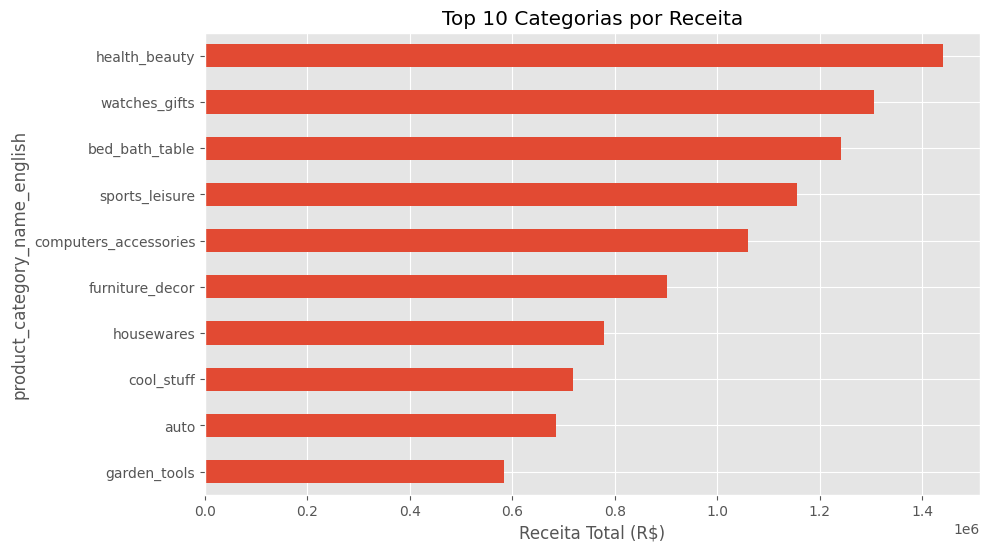

In [5]:
top10 = category_revenue.head(10)

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind="barh")
plt.title("Top 10 Categorias por Receita")
plt.xlabel("Receita Total (R$)")
plt.show()


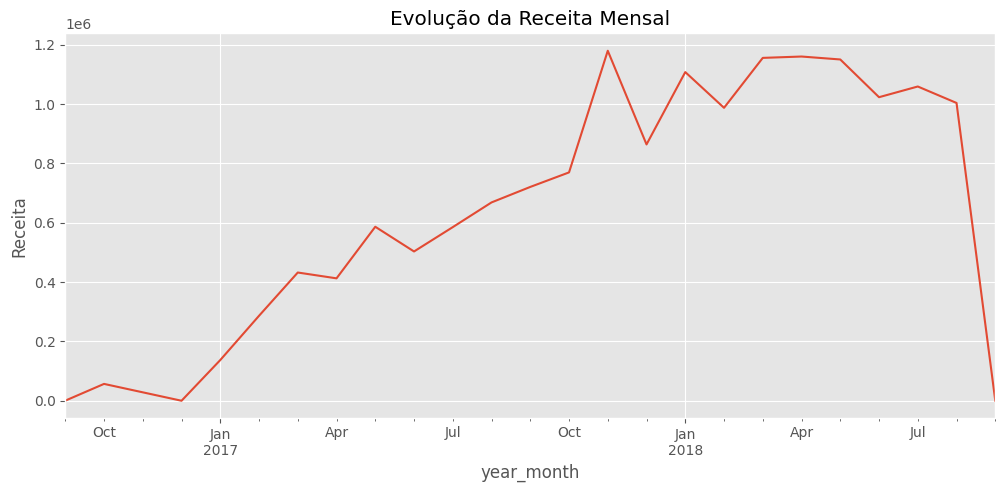

In [6]:
df["year_month"] = df["order_purchase_timestamp"].dt.to_period("M")

monthly_revenue = (
    df.groupby("year_month")["revenue"]
    .sum()
)

monthly_revenue.plot(figsize=(12,5))
plt.title("Evolução da Receita Mensal")
plt.ylabel("Receita")
plt.show()


In [7]:
seller_revenue = (
    df.groupby("seller_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

total_market = seller_revenue.sum()

top10_share = seller_revenue.head(10).sum() / total_market

top10_share


np.float64(0.12804682126974695)

O mercado apresenta baixa concentração, com os 10 maiores sellers representando apenas 12,8% da receita total. Isso sugere um ambiente altamente competitivo e fragmentado, com oportunidades para novos entrantes e estratégias de diferenciação.

In [8]:
state_revenue = (
    df.groupby("customer_state")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10)


,revenue
customer_state,
SP,5921678.12
RJ,2129681.98
MG,1856161.49
RS,885826.76
PR,800935.44
BA,611506.67
SC,610213.60
DF,353229.44
GO,347706.93


In [9]:
ticket_medio = df.groupby("order_id")["revenue"].sum().mean()
ticket_medio


np.float64(160.57763809214927)